VIKAASAN S
24BAD129

PART A: DATASET PREPARATION AND TEXT PREPROCESSING
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Positive reviews: 12500
Negative reviews: 12500
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample Review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the tw

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)


PART D: MODEL TRAINING AND SENTIMENT PREDICTION
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 164ms/step - accuracy: 0.5646 - loss: 0.6827 - val_accuracy: 0.5116 - val_loss: 0.6936
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 155ms/step - accuracy: 0.5904 - loss: 0.6450 - val_accuracy: 0.6000 - val_loss: 0.6702
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 151ms/step - accuracy: 0.6213 - loss: 0.6418 - val_accuracy: 0.7142 - val_loss: 0.6145
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 147ms/step - accuracy: 0.7546 - loss: 0.5424 - val_accuracy: 0.7312 - val_loss: 0.5716
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.7890 - loss: 0.4932 - val_accuracy: 0.7570 - val_loss: 0.5530

Training Results
Final Training Accuracy: 0.7889999747276306
Final Validation Accuracy: 0.7570000290870667
Final Training Loss: 0.49320244789123535
Final Validation Loss: 0.5530235767364502


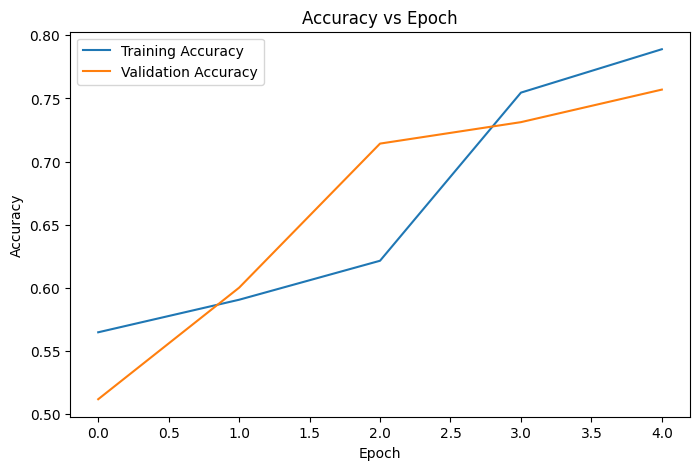

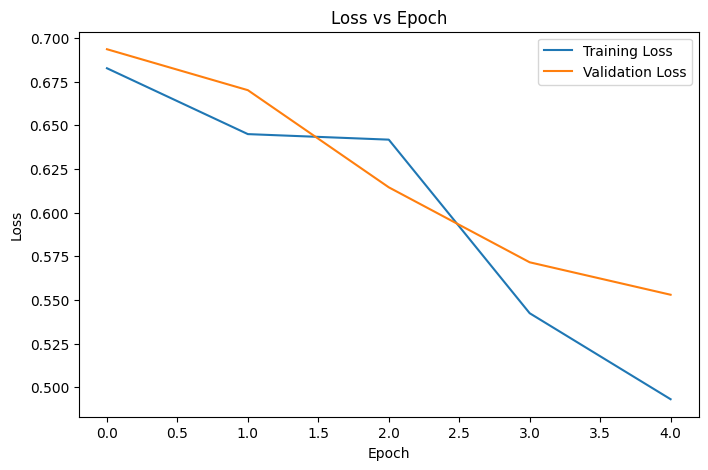


Test Loss: 0.5523813962936401
Test Accuracy: 0.7540799975395203

Evaluation Metrics
Accuracy : 0.75408
Precision: 0.7979921185963595
Recall   : 0.6804
F1-Score : 0.7345193885482338

Classification Report
              precision    recall  f1-score   support

    Negative       0.72      0.83      0.77     12500
    Positive       0.80      0.68      0.73     12500

    accuracy                           0.75     25000
   macro avg       0.76      0.75      0.75     25000
weighted avg       0.76      0.75      0.75     25000


Confusion Matrix
[[10347  2153]
 [ 3995  8505]]


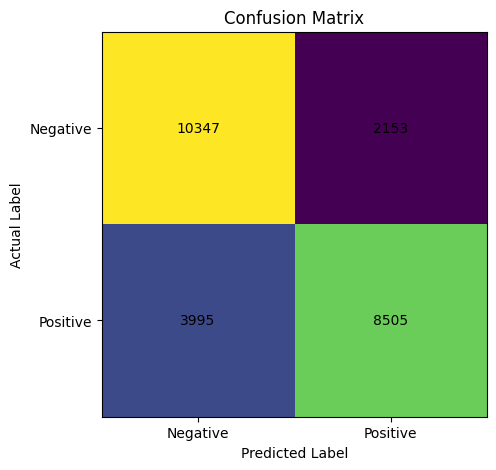


SAMPLE SENTIMENT PREDICTIONS

Review: This movie was excellent and I really enjoyed watching it
Prediction Score: 0.8244991
Predicted Sentiment: Positive

Review: The movie was boring and disappointing
Prediction Score: 0.27707195
Predicted Sentiment: Negative

Review: Amazing acting and wonderful story
Prediction Score: 0.8244991
Predicted Sentiment: Positive

Review: The film was terrible and very slow
Prediction Score: 0.27707025
Predicted Sentiment: Negative

EXPERIMENT COMPLETED


In [1]:
print("VIKAASAN S")
print("24BAD129")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

vocab_size = 10000
max_length = 200
embedding_dim = 128
lstm_units = 64
epochs = 5
batch_size = 64

print("\nPART A: DATASET PREPARATION AND TEXT PREPROCESSING")

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Positive reviews:", np.sum(y_train == 1))
print("Negative reviews:", np.sum(y_train == 0))

word_index = imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(review):
    return " ".join(reverse_word_index.get(i, "?") for i in review)

print("\nSample Review:")
print(decode_review(x_train[0]))

print("\nSample Label:")
print("Positive" if y_train[0] == 1 else "Negative")

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("\nAfter Padding:")
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nTraining data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

print("\nPART B: EMBEDDING GENERATION")

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_length
)

sample_embedding = embedding_layer(x_train[:1])

print("Embedding representation shape:", sample_embedding.shape)
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)

print("\nPART C: IMPLEMENTING THE LSTM MODEL")

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    LSTM(lstm_units),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, max_length))

print("\nModel Summary:")
model.summary()

print("\nPART D: MODEL TRAINING AND SENTIMENT PREDICTION")

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

print("\nTraining Results")

print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

y_probability = model.predict(
    x_test,
    verbose=0
)

y_pred = (y_probability >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

print("\nSAMPLE SENTIMENT PREDICTIONS")

sample_reviews = [
    "This movie was excellent and I really enjoyed watching it",
    "The movie was boring and disappointing",
    "Amazing acting and wonderful story",
    "The film was terrible and very slow"
]

word_index = imdb.get_word_index()

def encode_text(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        index = word_index.get(word, 2)

        if index >= vocab_size:
            index = 2

        encoded.append(index + 3)

    return encoded

for review in sample_reviews:

    sequence = encode_text(review)

    padded_sequence = pad_sequences(
        [sequence],
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    prediction = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    sentiment = "Positive" if prediction >= 0.5 else "Negative"

    print("\nReview:", review)
    print("Prediction Score:", prediction)
    print("Predicted Sentiment:", sentiment)

print("\nEXPERIMENT COMPLETED")
